# EDA - Profile
Esse notebook aplica uma breve EDA sobre `profile.json` para entender o tipo de dado presente neste arquivo, quantidade, colunas, tipos de oferta, e outras informações relevantes para o problema e para o processamento de dados.

Pontos observados neste primeiro momento:
1. Existem 2175 registros onde 'age=118' e 2175 nulos em 'gender' e 2175 nulos em 'credit_card_limit'. É o mesmo número nas três colunas. Entende-se que é referente ao _mesmo grupo de clientes_ com cadastro incompleto. Ou seja, não parece ser um dado real. Parece ser alguma regra de negócio determinística para quando o cliente não conclui o seu cadastro.
2. 'registered_on' nunca é nulo, mesmo para o grupo incompleto. Ou seja, a data de criação é sempre detectada, independente de existir cadastro completo ou não. Provavelmente o sistema realiza esse preenchimento automaticamente, o que independe do preenchimento do cadastro por parte do cliente.
3. O sumário, quando tiramos os clientes com 'age=118' mostram que, ao aplicar esse filtro, é removido exatamente o grupo de cadastros incompletos. Também podemos observar que a média de idade e o desvio-padrão cai bastante com essa remoção. Ou seja, esse caso onde 'age=118' estava distorcendo a média e também mexendo com a distribuição. Porém, por parecer ser uma regra de negócio para o cenário onde o cadastro fica incompleto, será possível tratar esse cenário.
4. 'gender' possui 4 categorias: 'F' (6129), 'M' (8484), 'O' (212) e 'NULL' (2175). O 'NULL', como vimos, pertence ao cenário onde 'age=118'. Já o 'O' pode ser tratado como uma terceira categoria até que se entenda melhor o seu caso, pois pode ser uma categoria "Outro" ou "Prefiro não informar".
5. 'credit_card_limit' varia de '30000' a '120000', com quartis exatos em '49000', '64000' e '80000'. Por haver '92' valores distintos, talvez seja possível criar buckets de valores para essa variável.
6. 'registered_on' possui um range de '2013-07-29' a '2018-07-26', ou seja, quase 5 anos de cobertura. Também, é possível observar uma breve divergência com relação ao documento do case aqui. Na documentação consta que essa variável é do tipo 'int', mas ela é do tipo 'string'.
7. 'id' é único e não possui nulos. 

In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Sessao Spark
spark = SparkSession.builder.appName("ifood-case").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/07/24 16:35:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# Leitura do arquivo profile.json
profile = spark.read.option("multiline", "true").json("../data/raw/profile.json")

In [4]:
# Exibicao do schema do arquivo profile.json
profile.show(n=10, truncate=False)

+---+-----------------+------+--------------------------------+-------------+
|age|credit_card_limit|gender|id                              |registered_on|
+---+-----------------+------+--------------------------------+-------------+
|118|NULL             |NULL  |68be06ca386d4c31939f3a4f0e3dd783|20170212     |
|55 |112000.0         |F     |0610b486422d4921ae7d2bf64640c50b|20170715     |
|118|NULL             |NULL  |38fe809add3b4fcf9315a9694bb96ff5|20180712     |
|75 |100000.0         |F     |78afa995795e4d85b5d9ceeca43f5fef|20170509     |
|118|NULL             |NULL  |a03223e636434f42ac4c3df47e8bac43|20170804     |
|68 |70000.0          |M     |e2127556f4f64592b11af22de27a7932|20180426     |
|118|NULL             |NULL  |8ec6ce2a7e7949b1bf142def7d0e0586|20170925     |
|118|NULL             |NULL  |68617ca6246f4fbc85e91a2a49552598|20171002     |
|65 |53000.0          |M     |389bc3fa690240e798340f5a15918d5c|20180209     |
|118|NULL             |NULL  |8974fc5686fe429db53ddde067b88302|2

In [5]:
# Tipo de dado nas colunas do arquivo profile.json
profile.printSchema()

root
 |-- age: long (nullable = true)
 |-- credit_card_limit: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- id: string (nullable = true)
 |-- registered_on: string (nullable = true)



In [6]:
print(
    f"Quantidade de linhas: {profile.count()}; Quantidade de colunas: {len(profile.columns)}"
)

Quantidade de linhas: 17000; Quantidade de colunas: 5


In [7]:
# Contagem de registros distintos - coluna "id"
print(profile.select("id").distinct().count())

17000


In [8]:
# Verificacao de valores nulos
profile.select(
    [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in profile.columns]
).show()

+---+-----------------+------+---+-------------+
|age|credit_card_limit|gender| id|registered_on|
+---+-----------------+------+---+-------------+
|  0|             2175|  2175|  0|            0|
+---+-----------------+------+---+-------------+



/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


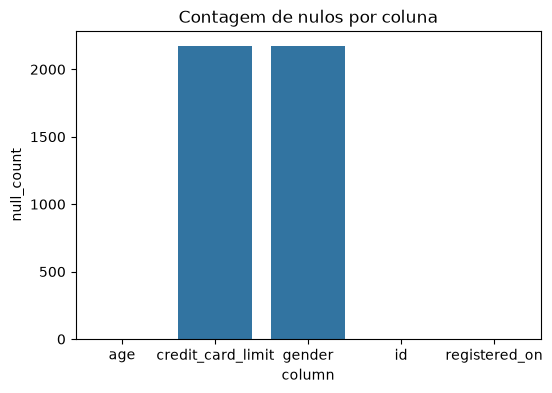

In [9]:
# Nulos por coluna
# Somente a coluna "credit_card_limit" e "gender" possuem valores nulos (isso foi mencionado acima).
null_counts = (
    profile.select(
        [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in profile.columns]
    )
    .toPandas()
    .T.reset_index()
)
null_counts.columns = ["column", "null_count"]

plt.figure(figsize=(6, 4))
sns.barplot(data=null_counts, x="column", y="null_count")
plt.title("Contagem de nulos por coluna")
plt.show();

In [10]:
profile.select("registered_on").show(10, truncate=False)

+-------------+
|registered_on|
+-------------+
|20170212     |
|20170715     |
|20180712     |
|20170509     |
|20170804     |
|20180426     |
|20170925     |
|20171002     |
|20180209     |
|20161122     |
+-------------+
only showing top 10 rows


In [11]:
# Estatistica descritiva da coluna "age"
profile.select("age").summary().show()

+-------+------------------+
|summary|               age|
+-------+------------------+
|  count|             17000|
|   mean| 62.53141176470588|
| stddev|26.738579945767256|
|    min|                18|
|    25%|                45|
|    50%|                58|
|    75%|                73|
|    max|               118|
+-------+------------------+



In [12]:
# Estatistica descritiva da coluna "age"
# Idade maxima < 118
profile.filter(profile.age < 118).select("age").summary().show()

+-------+------------------+
|summary|               age|
+-------+------------------+
|  count|             14825|
|   mean| 54.39352445193929|
| stddev|17.383705365855015|
|    min|                18|
|    25%|                42|
|    50%|                55|
|    75%|                66|
|    max|               101|
+-------+------------------+



In [13]:
# Estatistica descritiva
# Idade maxima < 118
profile.filter(profile.age < 118).select("age", "credit_card_limit").summary().show()

+-------+------------------+------------------+
|summary|               age| credit_card_limit|
+-------+------------------+------------------+
|  count|             14825|             14825|
|   mean| 54.39352445193929|  65404.9915682968|
| stddev|17.383705365855015|21598.299410229436|
|    min|                18|           30000.0|
|    25%|                42|           49000.0|
|    50%|                55|           64000.0|
|    75%|                66|           80000.0|
|    max|               101|          120000.0|
+-------+------------------+------------------+



/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


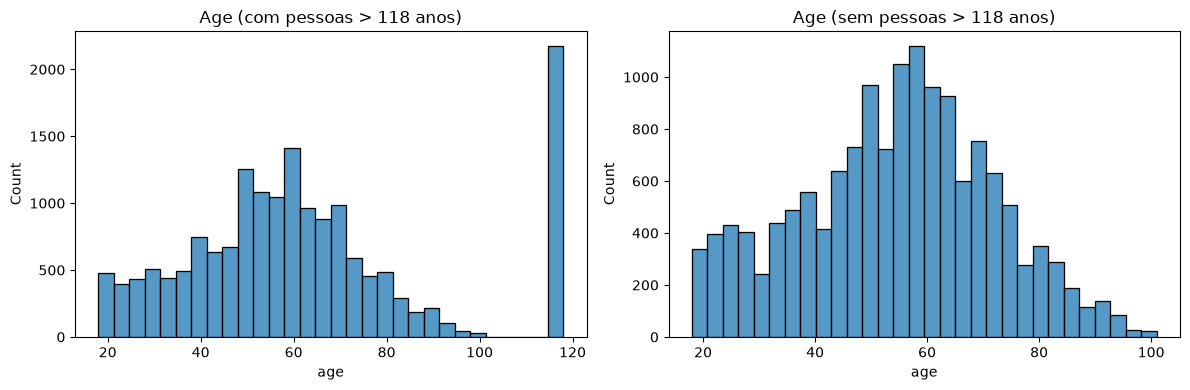

In [14]:
# Distribuicao de "age"
# Podemos observar uma boa diferenca na distribuicao de idade quando consideramos ou nao pessoas com idade maior que 118 anos.
# A distribuicao de idade com pessoas com idade maior que 118 anos apresenta um pico em 118 anos.
# A distribuicao de idade sem pessoas com idade maior que 118 anos apresenta uma distribuicao mais uniforme e realista.
age_pd = profile.select("age").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(age_pd["age"], bins=30, ax=axes[0])
axes[0].set_title("Age (com pessoas > 118 anos)")

sns.histplot(age_pd[age_pd["age"] < 118]["age"], bins=30, ax=axes[1])
axes[1].set_title("Age (sem pessoas > 118 anos)")

plt.tight_layout()
plt.show();

In [15]:
# Contagem de registros por idade
# Mais de 2000 pessoas com idade > 118?
profile.groupBy("age").count().orderBy(F.desc("count")).show(10)

+---+-----+
|age|count|
+---+-----+
|118| 2175|
| 58|  408|
| 53|  372|
| 51|  363|
| 54|  359|
| 59|  359|
| 57|  353|
| 52|  351|
| 55|  350|
| 56|  342|
+---+-----+
only showing top 10 rows


In [16]:
profile.filter(F.col("age") == 118).select(
    [
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in ["gender", "credit_card_limit", "registered_on"]
    ]
).show()

+------+-----------------+-------------+
|gender|credit_card_limit|registered_on|
+------+-----------------+-------------+
|  2175|             2175|            0|
+------+-----------------+-------------+



In [17]:
profile.groupBy("gender").count().show()

+------+-----+
|gender|count|
+------+-----+
|     F| 6129|
|  NULL| 2175|
|     M| 8484|
|     O|  212|
+------+-----+



In [18]:
# Estatistica descritiva de "credit_card_limit"
profile.select("credit_card_limit").summary().show()

+-------+------------------+
|summary| credit_card_limit|
+-------+------------------+
|  count|             14825|
|   mean|  65404.9915682968|
| stddev|21598.299410229436|
|    min|           30000.0|
|    25%|           49000.0|
|    50%|           64000.0|
|    75%|           80000.0|
|    max|          120000.0|
+-------+------------------+



/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


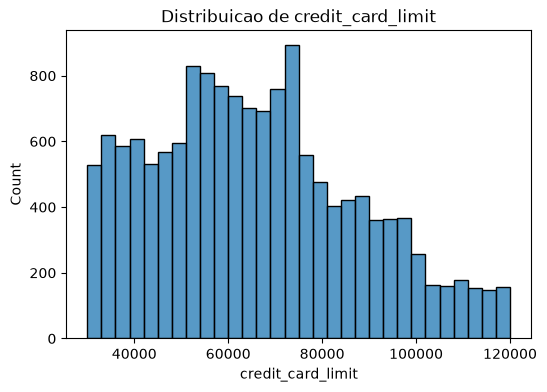

In [19]:
# Distribuicao de "credit_card_limit"
# Podemos observar que a distribuicao de "credit_card_limit" possui maior concentracao de valores a esquerda, com uma
# cauda de valores mais altos a direita.
limit_pd = profile.select("credit_card_limit").dropna().toPandas()

plt.figure(figsize=(6, 4))
sns.histplot(limit_pd["credit_card_limit"], bins=30)
plt.title("Distribuicao de credit_card_limit")
plt.show();

In [20]:
# Contagem de registros distintos - coluna "credit_card_limit"
# Buckets de valores para limite de credito?
profile.select("credit_card_limit").distinct().count()

92

In [21]:
# Data minima e maxima de "registered_on"
profile.select(
    F.min("registered_on").alias("min_registered_on"),
    F.max("registered_on").alias("max_registered_on"),
).show()

+-----------------+-----------------+
|min_registered_on|max_registered_on|
+-----------------+-----------------+
|         20130729|         20180726|
+-----------------+-----------------+



/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


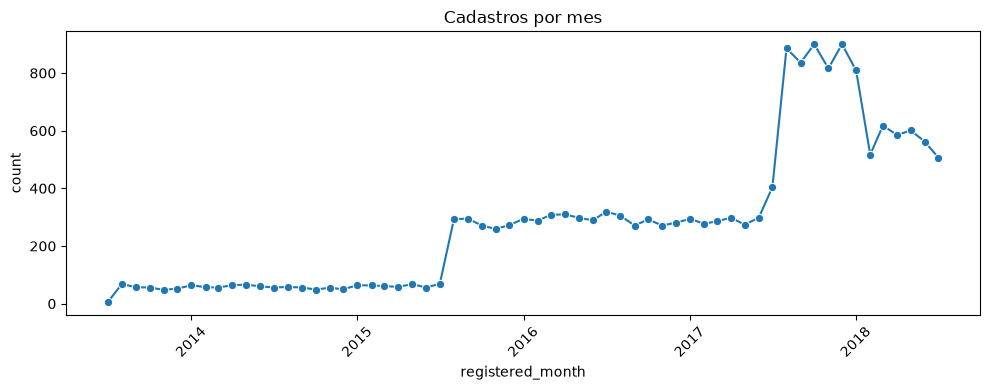

In [22]:
# Cadastros por mes
# Podemos observar que o numero de cadastros por mes apresenta um aumento significativo entre 2017 e 2018,
# com uma diminuicao apos entrar em 2018.
registrations_pd = (
    profile.withColumn("registered_date", F.to_date("registered_on", "yyyyMMdd"))
    .withColumn("registered_month", F.date_trunc("month", "registered_date"))
    .groupBy("registered_month")
    .count()
    .orderBy("registered_month")
    .toPandas()
)

plt.figure(figsize=(10, 4))
sns.lineplot(data=registrations_pd, x="registered_month", y="count", marker="o")
plt.title("Cadastros por mes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/mnt/HD2/Data_Science/ifood-case/.venv/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


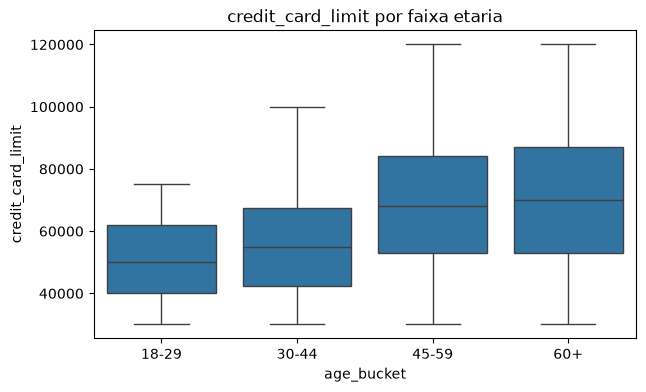

In [23]:
# Distribuicao de "credit_card_limit" por faixa etaria
# Podemos observar que a distribuicao de "credit_card_limit" por faixa etaria apresenta uma tendencia clara de aumento do
# limite de credito com o aumento da idade.
age_limit_pd = (
    profile.filter(F.col("age") < 118)
    .withColumn(
        "age_bucket",
        F.when(F.col("age") < 30, "18-29")
        .when(F.col("age") < 45, "30-44")
        .when(F.col("age") < 60, "45-59")
        .otherwise("60+"),
    )
    .select("age_bucket", "credit_card_limit")
    .toPandas()
)

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=age_limit_pd,
    x="age_bucket",
    y="credit_card_limit",
    order=["18-29", "30-44", "45-59", "60+"],
)
plt.title("credit_card_limit por faixa etaria")
plt.show()